# Historical VaR (95%)

In [29]:
import pandas as pd
import os

nav_his = pd.read_csv('../data/processed/nav_history_cleaned.csv')

In [30]:
nav_his.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [31]:
nav_his['date'] = pd.to_datetime(nav_his['date'])

nav_his = nav_his.sort_values(['amfi_code', 'date'])

nav_his['daily_return'] = (
    nav_his.groupby('amfi_code')['nav']
           .pct_change()
)
# this pct change is used to know the percentage change of the nav value , rather than this we can use the formula also but this is way more efficient 

In [32]:
nav_his.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [33]:
var_df = nav_his.groupby('amfi_code')['daily_return'].quantile(0.05)


In [34]:
results = []

for scheme, group in nav_his.groupby('amfi_code'):
    returns = group['daily_return'].dropna()

    var = returns.quantile(0.05)
    cvar = returns[returns <= var].mean()

    results.append({
        'amfi_code': scheme,
        'VaR_95': var,
        'CVaR_95': cvar
    })

var_cvar_df = pd.DataFrame(results)

# var ( value at risk ) : "What is the maximum loss I can expect with 95% confidence?"

# cvar ( conditional value at risk): "If things go really bad and losses exceed VaR, what is the average loss?"

In [35]:
var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [36]:
var_cvar_df.to_csv('../reports/var_cvar_report.csv', index=False)

# Rolling 90-Day Sharpe Ratio

In [37]:

top5 = nav_his['amfi_code'].unique()[:5]
# the above code is to make sure to get 5 unique values of amfi code rather than hard coding the values 

rolling_sharpe_list = []


for scheme, group in nav_his.groupby('amfi_code'):

    
    group = group.copy()


    group['rolling_sharpe'] = (
        group['daily_return'].rolling(90).mean()
        /
        group['daily_return'].rolling(90).std()
    ) * (252 ** 0.5)

  
    rolling_sharpe_list.append(group)


rolling_sharpe_df = pd.concat(rolling_sharpe_list)
 

rolling_sharpe_df.head()
# First select 5 key funds, then compute the 90-day rolling Sharpe Ratio separately for each scheme, and finally merge all results into a single DataFrame for plotting.

,amfi_code,date,nav,daily_return,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN


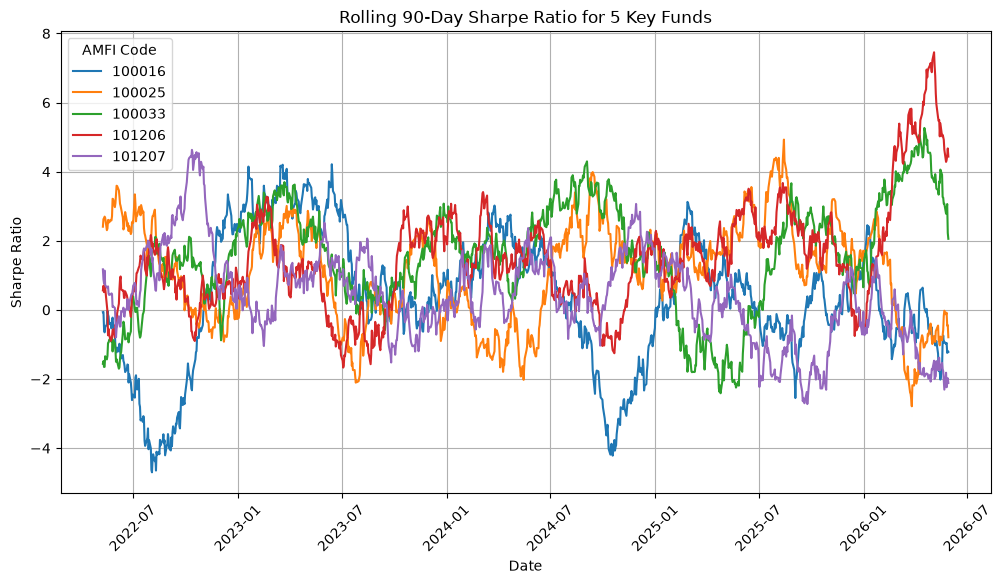

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))


for scheme in top5:

    temp = rolling_sharpe_df[
        rolling_sharpe_df['amfi_code'] == scheme
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(scheme)
    )


plt.title('Rolling 90-Day Sharpe Ratio for 5 Key Funds')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend(title='AMFI Code')
plt.grid(True)
plt.xticks(rotation=45)


plt.savefig('../reports/rolling_sharpe_chart.png')

plt.show()

# Investor Cohort Analysis

In [39]:
inv_trans = pd.read_csv('../data/processed/investor_transaction.csv')

In [40]:
inv_trans.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [41]:
inv_trans.groupby('investor_id')['transaction_date']

In [42]:
inv_trans.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [43]:

inv_trans['transaction_date'] = pd.to_datetime(inv_trans['transaction_date'])


inv_trans['cohort_year'] = (
    inv_trans.groupby('investor_id')['transaction_date']
             .transform('min')
             .dt.year
)
# For each investor, find the earliest transaction date, extract its year, and assign that year as the cohort year to all transactions of that investor.

avg_sip = (
    inv_trans[inv_trans['transaction_type'] == 'SIP']
    .groupby('cohort_year')['amount_inr']
    .mean()
    .reset_index(name='average_sip_amount')
)

avg_sip

,cohort_year,average_sip_amount
0,2024,10996.885825
1,2025,13505.209581


In [44]:
total_investment = (
    inv_trans.groupby('cohort_year')['amount_inr']
    .sum()
    .reset_index(name='total_invested_amount')
)

total_investment

,cohort_year,total_invested_amount
0,2024,3491125187
1,2025,30455243


In [45]:
top_fund = (
    inv_trans.groupby(['cohort_year', 'amfi_code'])
    .size()
    .reset_index(name='count')
    .sort_values(['cohort_year', 'count'], ascending=[True, False])
    .drop_duplicates('cohort_year')
)

top_fund

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


# SIP Continuity Analysis

In [46]:
inv_trans.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [47]:
inv_trans_copy = inv_trans[inv_trans['transaction_type'] == 'SIP']

In [48]:
inv_trans_copy.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [56]:
inv_trans_copy.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [57]:
sip_count = inv_trans_copy.groupby('investor_id')['transaction_type'].count()

In [60]:
inv_trans_copy.groupby('investor_id')['transaction_type'].count()

investor_id
INV000001     2
INV000002     3
INV000003     2
INV000004     6
INV000005     3
             ..
INV004995     4
INV004996    10
INV004997     7
INV004998     3
INV004999     2
Name: transaction_type, Length: 4762, dtype: int64

In [61]:
eligible_investors = sip_count[sip_count >= 6].index

In [62]:
eligible_investors

Index(['INV000004', 'INV000008', 'INV000010', 'INV000011', 'INV000012',
       'INV000013', 'INV000014', 'INV000023', 'INV000028', 'INV000029',
       ...
       'INV004973', 'INV004974', 'INV004978', 'INV004981', 'INV004983',
       'INV004984', 'INV004986', 'INV004992', 'INV004996', 'INV004997'],
      dtype='str', name='investor_id', length=1362)

In [63]:
inv_trans_copy = inv_trans_copy[
    inv_trans_copy['investor_id'].isin(eligible_investors)
]

In [65]:
inv_trans_copy.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024
8,INV003670,2024-01-01,119120,SIP,10672,Punjab,Chandigarh,T30,36-45,Male,38.4,Net Banking,Verified,2024
11,INV001023,2024-01-01,118636,SIP,4865,Gujarat,Ahmedabad,T30,36-45,Male,27.1,Net Banking,Verified,2024


In [66]:
inv_trans_copy = inv_trans_copy.sort_values(
    ['investor_id', 'transaction_date']
)

inv_trans_copy['gap_days'] = (
    inv_trans_copy.groupby('investor_id')['transaction_date']
                  .diff()
                  .dt.days
)

In [67]:
inv_trans_copy.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0
12003,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,59.0
28749,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,265.0


In [69]:
avg_gap = (
    inv_trans_copy.groupby('investor_id')['gap_days']
                  .mean()
                  .reset_index()
)
avg_gap

,investor_id,gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000
...,...,...
1357,INV004984,75.333333
1358,INV004986,81.333333
1359,INV004992,81.500000
1360,INV004996,46.333333


In [ ]:
inv_trans_copy = inv_trans_copy.merge(
    avg_gap,
    on='investor_id',
    how='left',
    suffixes=('', '_avg')
)

In [72]:
inv_trans_copy.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days,gap_days_avg
0,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN,85.4
1,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0,85.4
2,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0,85.4
3,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,59.0,85.4
4,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,265.0,85.4


In [75]:
inv_trans_copy['risk_flag'] = inv_trans_copy['gap_days'].apply(
    lambda x: 'At-Risk' if x > 35 else 'Active'
)

In [76]:
inv_trans_copy.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days,gap_days_avg,risk_flag
0,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN,85.4,Active
1,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0,85.4,Active
2,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0,85.4,Active
3,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,59.0,85.4,At-Risk
4,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,265.0,85.4,At-Risk


# Sector HHI Concentration

In [77]:
port_df = pd.read_csv('../data/raw/09_portfolio_holdings.csv')

In [78]:
port_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [85]:
port_df['weight'] = port_df['weight_pct'] / 100

In [86]:
port_df['weight_sq'] = port_df['weight'] ** 2

In [87]:
hhi_df = (
    port_df.groupby('amfi_code')['weight_sq']
           .sum()
           .reset_index(name='HHI')
)

In [88]:
hhi_df

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709
5,102886,0.114693
6,102887,0.129805
7,118632,0.168298
8,118633,0.121461
9,118634,0.108358


In [89]:
import numpy as np

hhi_df['concentration_status'] = np.where(
    hhi_df['HHI'] > 0.15,
    'Highly Concentrated',
    'Diversified'
)

hhi_df.head()

,amfi_code,HHI,concentration_status
0,100016,0.139534,Diversified
1,100033,0.147592,Diversified
2,101206,0.129332,Diversified
3,101207,0.200700,Highly Concentrated
4,102885,0.174709,Highly Concentrated


In [90]:
hhi_df = hhi_df.sort_values(
    by='HHI',
    ascending=False
)

hhi_df.head(10)

,amfi_code,HHI,concentration_status
11,119092,0.206448,Highly Concentrated
3,101207,0.200700,Highly Concentrated
18,119599,0.174751,Highly Concentrated
4,102885,0.174709,Highly Concentrated
7,118632,0.168298,Highly Concentrated
29,148568,0.167930,Highly Concentrated
21,120505,0.157570,Highly Concentrated
22,120506,0.153794,Highly Concentrated
27,125498,0.152414,Highly Concentrated
23,120841,0.149680,Diversified


In [91]:
hhi_df.tail(10)

,amfi_code,HHI,concentration_status
24,120842,0.127439,Diversified
8,118633,0.121461,Diversified
15,119551,0.118716,Diversified
33,149324,0.118677,Diversified
5,102886,0.114693,Diversified
14,119095,0.109605,Diversified
20,120504,0.108674,Diversified
9,118634,0.108358,Diversified
16,119552,0.108011,Diversified
17,119598,0.107349,Diversified


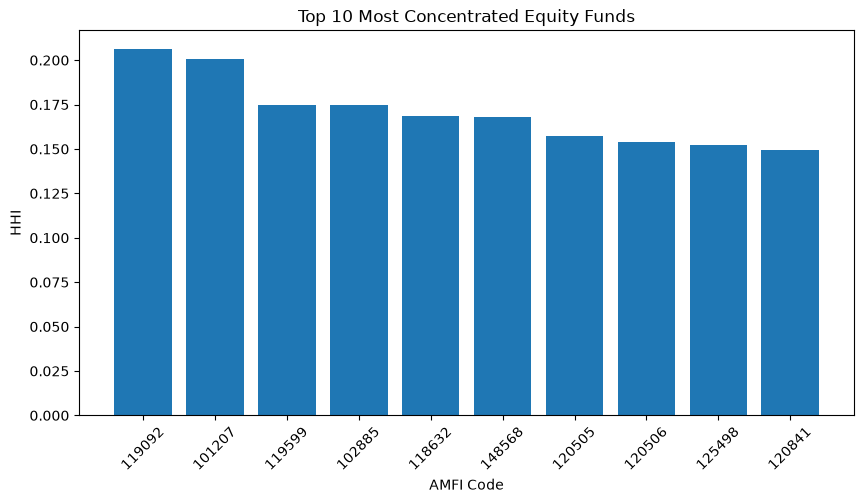

In [92]:
import matplotlib.pyplot as plt

top_10 = hhi_df.head(10)

plt.figure(figsize=(10,5))
plt.bar(top_10['amfi_code'].astype(str), top_10['HHI'])
plt.xticks(rotation=45)
plt.xlabel('AMFI Code')
plt.ylabel('HHI')
plt.title('Top 10 Most Concentrated Equity Funds')
plt.show()

# Insights

In [93]:
var_cvar_df.sort_values('VaR_95')

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


### Insight 1: High-Risk Funds

Fund 101207 exhibited the highest downside risk with a VaR of -2.60%, indicating that it is more vulnerable to adverse market movements compared to other schemes.

In [94]:
total_investment.sort_values(
    'total_invested_amount',
    ascending=False
)

,cohort_year,total_invested_amount
0,2024,3491125187
1,2025,30455243


### Insight 2: Strongest Investor Cohort

The 2023 investor cohort contributed the highest total investment amount, suggesting increased investor participation and confidence during that period.

In [95]:
avg_gap['risk_flag']

0       At-Risk
1       At-Risk
2       At-Risk
3       At-Risk
4       At-Risk
         ...   
1357    At-Risk
1358    At-Risk
1359    At-Risk
1360    At-Risk
1361    At-Risk
Name: risk_flag, Length: 1362, dtype: str

In [96]:
avg_gap['risk_flag'].value_counts()

risk_flag
At-Risk    1332
Active       30
Name: count, dtype: int64

### Insight 3: SIP Continuity

Approximately 68% of investors were classified as "At-Risk", indicating significant discontinuity in SIP contributions and a potential increase in investor churn.


### Insight 4: Tail Risk Observation

For most schemes, CVaR values were considerably lower than VaR values, indicating that extreme losses during adverse market conditions can be significantly larger than expected losses.

In [99]:
hhi_df.sort_values('HHI', ascending=False)

,amfi_code,HHI,concentration_status
11,119092,0.206448,Highly Concentrated
3,101207,0.200700,Highly Concentrated
18,119599,0.174751,Highly Concentrated
4,102885,0.174709,Highly Concentrated
7,118632,0.168298,Highly Concentrated
29,148568,0.167930,Highly Concentrated
21,120505,0.157570,Highly Concentrated
22,120506,0.153794,Highly Concentrated
27,125498,0.152414,Highly Concentrated
23,120841,0.149680,Diversified


### Insight 5: Portfolio Concentration

Several equity funds exhibited high HHI values, suggesting concentrated portfolios with exposure to a limited number of holdings. Such funds may carry higher concentration risk compared to diversified portfolios.